# 03 - Training
## Objectif : Comparer Linear Regression, Random Forest, XGBoost, LightGBM

In [344]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.tree import DecisionTreeRegressor


warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)

print("✅ Imports OK")

✅ Imports OK


In [345]:
df_ml = pd.read_csv('/app/notebooks/ml_dataset.csv', parse_dates=['date'])

with open('/app/notebooks/selected_features.json') as f:
    FEATURES = json.load(f)

TARGET = 'total_sales'

X = df_ml[FEATURES]
y = df_ml[TARGET]

print(f"✅ Dataset : {df_ml.shape}")
print(f"✅ Features ({len(FEATURES)}) : {FEATURES}")
print(f"Période : {df_ml['date'].min().strftime('%b %Y')} → {df_ml['date'].max().strftime('%b %Y')}")

✅ Dataset : (37, 15)
✅ Features (12) : ['is_january', 'is_summer', 'is_end_year', 'lag_1', 'semester', 'rolling_mean_3', 'month', 'quarter', 'lag_12', 'nb_documents', 'nb_clients', 'total_quantity']
Période : Jan 2023 → Jan 2026


## 1. Split temporel Train / Test (90/10)

Train : 33 mois (Jan 2023 → Sep 2025)
Test  : 4 mois (Oct 2025 → Jan 2026)


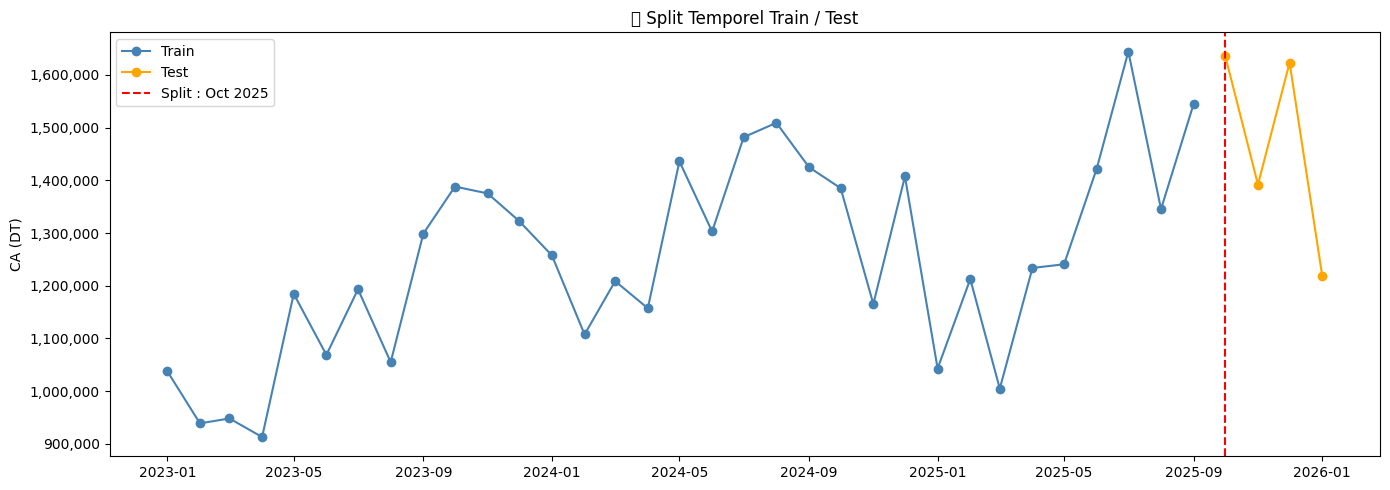

In [346]:
split_idx = int(len(df_ml) * 0.9)

split_date = df_ml.iloc[split_idx]['date']

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
df_train = df_ml.iloc[:split_idx]
df_test  = df_ml.iloc[split_idx:]

# Normalisation pour Linear Regression
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print(f"Train : {len(X_train)} mois ({df_train['date'].min().strftime('%b %Y')} → {df_train['date'].max().strftime('%b %Y')})")
print(f"Test  : {len(X_test)} mois ({df_test['date'].min().strftime('%b %Y')} → {df_test['date'].max().strftime('%b %Y')})")

# Visualiser le split
fig, ax = plt.subplots()
ax.plot(df_train['date'], y_train, label='Train', color='steelblue', marker='o')
ax.plot(df_test['date'],  y_test,  label='Test',  color='orange',    marker='o')
ax.axvline(split_date, color='red', linestyle='--',
           label=f'Split : {split_date.strftime("%b %Y")}')
ax.set_title('📊 Split Temporel Train / Test')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 2. Comparaison des 4 modèles

In [347]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2   = r2_score(y_te, pred)
    mape = np.mean(np.abs((y_te - pred) / y_te)) * 100
    smape = np.mean(2 * np.abs(y_te - pred) /
                   (np.abs(y_te) + np.abs(pred))) * 100
    bias = np.mean(pred - y_te)
    return {
        'name': name, 'model': model, 'pred': pred,
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'MAPE': mape, 'SMAPE': smape, 'Biais': bias
    }

models_config = [
    ("LinearRegression", LinearRegression(),         X_train_sc, X_test_sc),
    ("Ridge",            Ridge(alpha=10),             X_train_sc, X_test_sc),
    ("DecisionTree",     DecisionTreeRegressor(
                            max_depth=3,
                            random_state=42),         X_train,    X_test),
    ("RandomForest",     RandomForestRegressor(
                            n_estimators=100,
                            max_depth=20,
                            random_state=42),         X_train,    X_test),
    ("XGBoost",          XGBRegressor(
                            n_estimators=300,
                            max_depth=3,
                            learning_rate=0.03,
                            random_state=42),         X_train,    X_test),
]

results = []
for name, model, Xtr, Xte in models_config:
    r = evaluate(name, model, Xtr, y_train, Xte, y_test)
    results.append(r)

df_results = pd.DataFrame(results).set_index('name')

print("=" * 75)
print(f"{'Modèle':<20} {'MAE':>12} {'RMSE':>12} {'R²':>8} {'MAPE':>8} {'SMAPE':>8}")
print("=" * 75)
for _, row in df_results.iterrows():
    print(f"{row.name:<20} {row['MAE']:>12,.0f} {row['RMSE']:>12,.0f} "
          f"{row['R²']:>8.4f} {row['MAPE']:>7.2f}% {row['SMAPE']:>7.2f}%")
print("=" * 75)

best_name = df_results['MAPE'].idxmin()
print(f"\n🏆 Meilleur modèle : {best_name} (MAPE = {df_results.loc[best_name,'MAPE']:.2f}%)")

Modèle                        MAE         RMSE       R²     MAPE    SMAPE
LinearRegression           56,605       72,908   0.8231    4.23%    4.09%
Ridge                      63,877       65,601   0.8568    4.32%    4.34%
DecisionTree               80,488      107,309   0.6168    5.73%    5.47%
RandomForest               73,777       78,024   0.7974    5.04%    5.05%
XGBoost                    70,709       75,054   0.8125    5.10%    4.99%

🏆 Meilleur modèle : LinearRegression (MAPE = 4.23%)


## 3. Visualisation Réel vs Prédit — tous les modèles

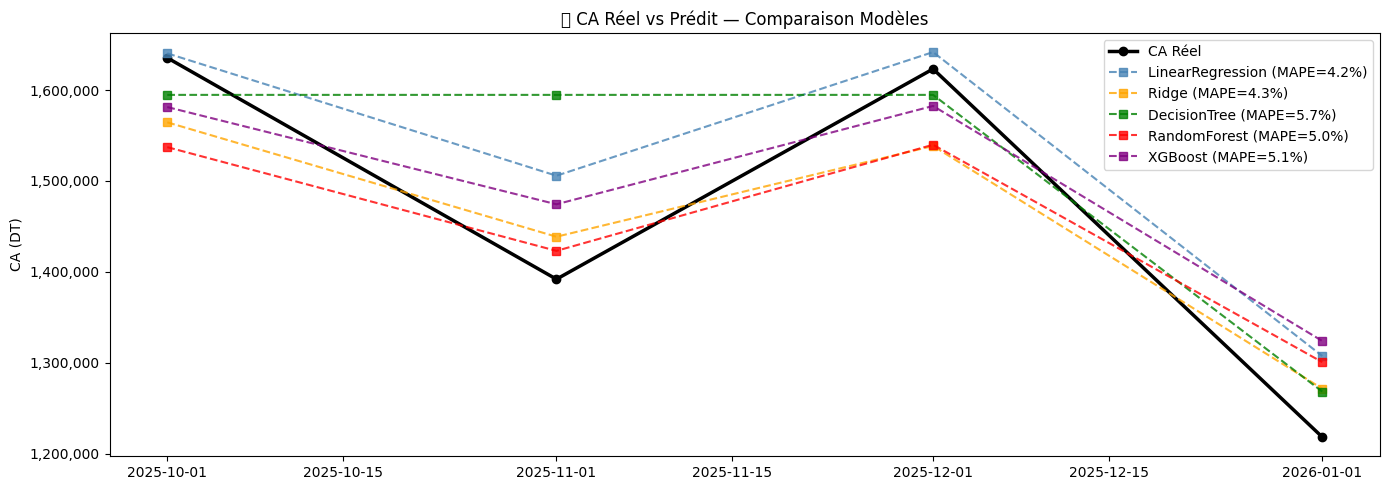

In [348]:
fig, ax = plt.subplots()

ax.plot(df_test['date'], y_test.values,
        label='CA Réel', color='black', marker='o', linewidth=2.5)

colors = ['steelblue', 'orange', 'green', 'red', 'purple']
for (_, row), color in zip(df_results.iterrows(), colors):
    ax.plot(df_test['date'], row['pred'],
            label=f"{row.name} (MAPE={row['MAPE']:.1f}%)",
            marker='s', linestyle='--', color=color, alpha=0.8)

ax.set_title('📈 CA Réel vs Prédit — Comparaison Modèles')
ax.set_ylabel('CA (DT)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

## 4. Détail mois par mois — meilleur modèle

In [349]:
best = df_results.loc[best_name]

df_detail = df_test[['date']].copy()
df_detail['reel']   = y_test.values
df_detail['predit'] = best['pred']
df_detail['ecart']  = best['pred'] - y_test.values
df_detail['ecart%'] = (df_detail['ecart'] / df_detail['reel'] * 100).round(2)

print(f"=== Détail {best_name} ===\n")
print(df_detail.to_string(index=False))
print(f"\nBiais : {best['Biais']:,.2f} DT  ({'surestimation' if best['Biais'] > 0 else 'sous-estimation'})")

=== Détail LinearRegression ===

      date         reel       predit      ecart  ecart%
2025-10-01 1,635,378.39 1,640,309.38   4,930.99    0.30
2025-11-01 1,391,948.18 1,505,738.80 113,790.62    8.17
2025-12-01 1,623,158.26 1,641,718.52  18,560.26    1.14
2026-01-01 1,218,358.52 1,307,495.80  89,137.27    7.32

Biais : 56,604.79 DT  (surestimation)


## 5. Cross-validation temporelle

In [350]:
tscv = TimeSeriesSplit(n_splits=5)

best_model_obj = df_results.loc[best_name, 'model']
use_scaler = best_name in ['LinearRegression', 'Ridge']

cv_scores = []
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X)):
    Xtr = scaler.fit_transform(X.iloc[tr_idx]) if use_scaler else X.iloc[tr_idx]
    Xval = scaler.transform(X.iloc[val_idx])   if use_scaler else X.iloc[val_idx]
    ytr, yval = y.iloc[tr_idx], y.iloc[val_idx]

    m = type(best_model_obj)(**best_model_obj.get_params())
    m.fit(Xtr, ytr)
    pred = m.predict(Xval)

    mae_cv  = mean_absolute_error(yval, pred)
    mape_cv = np.mean(np.abs((yval - pred) / yval)) * 100
    r2_cv   = r2_score(yval, pred)
    cv_scores.append({'fold': fold+1, 'MAE': mae_cv, 'MAPE': mape_cv, 'R²': r2_cv})
    print(f"Fold {fold+1} → MAE: {mae_cv:>12,.0f} DT | MAPE: {mape_cv:>6.2f}% | R²: {r2_cv:.4f}")

df_cv = pd.DataFrame(cv_scores)
print(f"\nMAE  moyenne : {df_cv['MAE'].mean():,.0f} DT ± {df_cv['MAE'].std():,.0f}")
print(f"MAPE moyenne : {df_cv['MAPE'].mean():.2f}% ± {df_cv['MAPE'].std():.2f}%")
print(f"R²   moyen   : {df_cv['R²'].mean():.4f} ± {df_cv['R²'].std():.4f}")

Fold 1 → MAE:       48,733 DT | MAPE:   3.73% | R²: 0.7710
Fold 2 → MAE:      512,457 DT | MAPE:  40.21% | R²: -16.3789
Fold 3 → MAE:       73,881 DT | MAPE:   6.25% | R²: 0.6219
Fold 4 → MAE:       77,519 DT | MAPE:   6.01% | R²: 0.7590
Fold 5 → MAE:       55,065 DT | MAPE:   3.98% | R²: 0.7903

MAE  moyenne : 153,531 DT ± 201,015
MAPE moyenne : 12.04% ± 15.79%
R²   moyen   : -2.6873 ± 7.6541


In [351]:
import joblib

# Réentraîner sur TOUT le dataset
print(f"Réentraînement sur {len(X)} mois complets...")
scaler_final = StandardScaler()

if best_name in ['LinearRegression', 'Ridge']:
    X_full_sc    = scaler_final.fit_transform(X)
    model_final  = type(best['model'])(**best['model'].get_params())
    model_final.fit(X_full_sc, y)
else:
    model_final = type(best['model'])(**best['model'].get_params())
    model_final.fit(X, y)
    scaler_final = scaler  # pas utilisé mais sauvegardé pour cohérence

joblib.dump(model_final,  '/app/notebooks/best_model.pkl')
joblib.dump(scaler_final, '/app/notebooks/scaler.pkl')

with open('/app/notebooks/best_model_name.json', 'w') as f:
    json.dump({'name': best_name, 'mape': float(best['MAPE'])}, f)

with open('/app/notebooks/features_corr.json', 'w') as f:
    json.dump(list(FEATURES), f)

print(f"✅ Modèle final sauvegardé : {best_name}")
print(f"   Entraîné sur : {len(X)} mois")
print(f"   MAPE test    : {best['MAPE']:.2f}%")

Réentraînement sur 37 mois complets...
✅ Modèle final sauvegardé : LinearRegression
   Entraîné sur : 37 mois
   MAPE test    : 4.23%
